# XGBoost Return Forecasting — All 3 Models

Trains and evaluates three XGBoost models that forecast each coin's **7-day-ahead price** on the test set. Each model is trained independently per coin (8 coins total). Forecasts are evaluated at each 7-day rebalance step and outputs are consumed by CMVO for portfolio optimisation.

---

## Models

### Model 1 — XGBoost Base
- **Features:** 14 lagged close prices
- **Target:** Close price 7 days ahead (direct price prediction)
- **Split:** 80/20 train/test
- **Hyperparameters:** Fixed (`n_estimators=300`, `max_depth=6`, `lr=0.05`)
- **Output:** `xgboost_forecasts.csv`, RMSE1_normalized.csv`

### Model 2 — XGBoost Features
- **Features:** 14 lagged log returns + 30/60-day rolling volatility (lagged)
- **Target:** Log return 7 days ahead â†’ converted back to price
- **Split:** 80/20 train/test
- **Hyperparameters:** Fixed (same as Base)
- **Output:** `xgb_feature_forecasts.csv`, `xgb_feature_rmses.csv`

### Model 3 — XGBoost Bayesian Optimised (BO)
- **Features:** 14 lagged close prices + 7-day rolling volatility
- **Target:** Close price 7 days ahead
- **Split:** 60/20/20 train/val/test
- **Hyperparameters:** Tuned with Optuna (30 trials, minimising val RMSE)
- **Output:** `xgboost_forecasts_BO_price_vol.csv`, `xgboost_rmse_summary_BO_price_vol.csv`

---

**Note:** Output CSVs are saved to the notebook's working directory. Tiny-price coins (median < 0.01) are log-transformed before training and inverse-transformed for evaluation.

In [1]:
import os
print(os.listdir("klines csv data/prices_cleaned"))

['ADAUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'TRXUSDT', 'XRPUSDT']


## Model 1 — XGBoost Base


Training: ADAUSDT
ADAUSDT RMSE: 0.160889
ADAUSDT Mean Actual Price: 0.528646
ADAUSDT NRMSE (% of mean price): 0.3043%


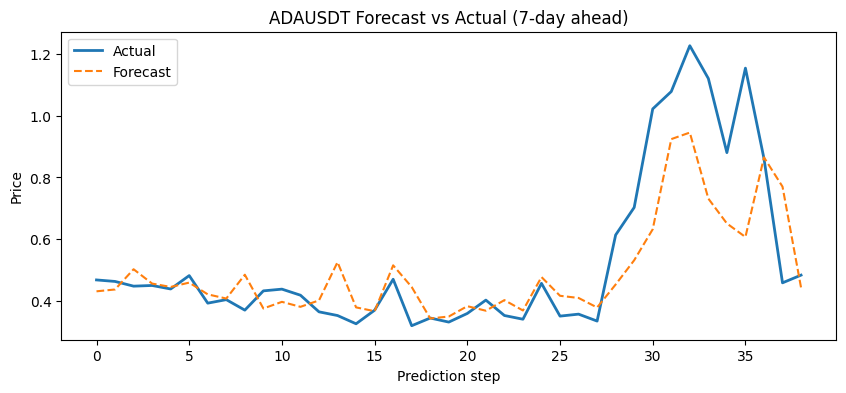


Training: BCHUSDT
BCHUSDT RMSE: 88.484263
BCHUSDT Mean Actual Price: 367.982051
BCHUSDT NRMSE (% of mean price): 0.2405%


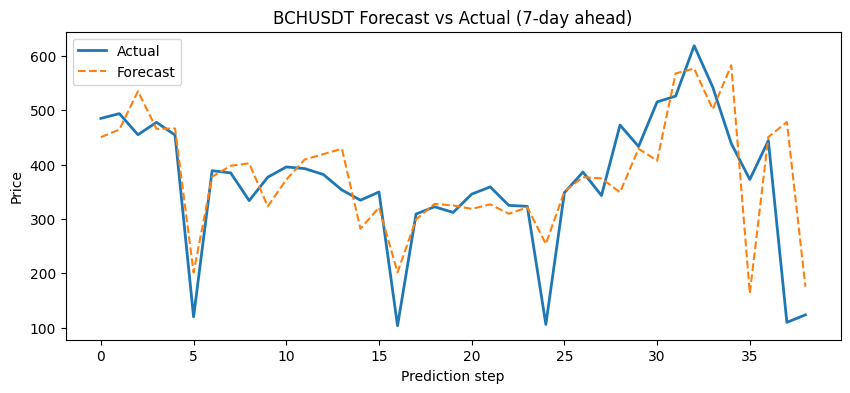


Training: BNBUSDT
BNBUSDT RMSE: 91.077701
BNBUSDT Mean Actual Price: 545.711282
BNBUSDT NRMSE (% of mean price): 0.1669%


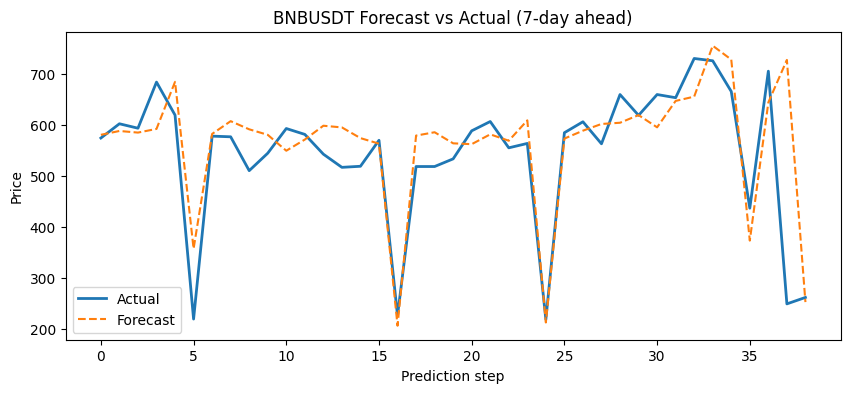


Training: BTCUSDT
BTCUSDT RMSE: 14863.288045
BTCUSDT Mean Actual Price: 64286.045128
BTCUSDT NRMSE (% of mean price): 0.2312%


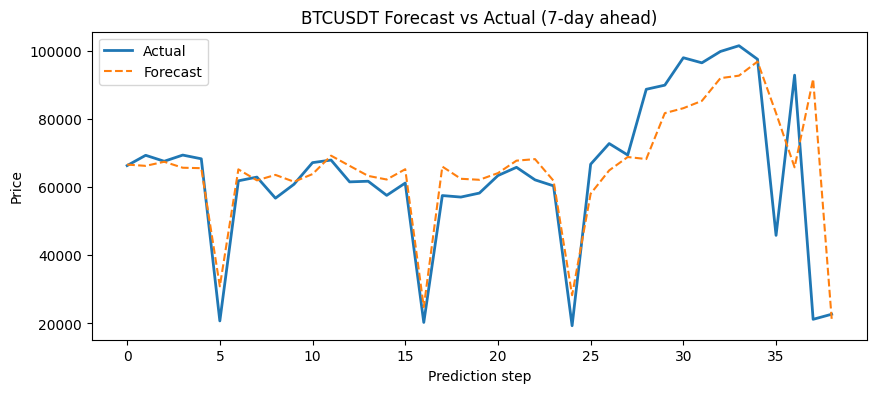


Training: ETHUSDT
ETHUSDT RMSE: 543.011128
ETHUSDT Mean Actual Price: 2851.582564
ETHUSDT NRMSE (% of mean price): 0.1904%


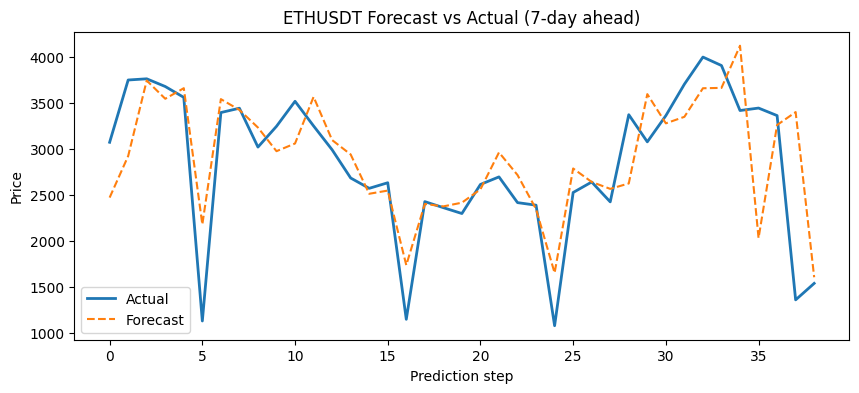


Training: SOLUSDT
SOLUSDT RMSE: 32.606461
SOLUSDT Mean Actual Price: 152.974615
SOLUSDT NRMSE (% of mean price): 0.2131%


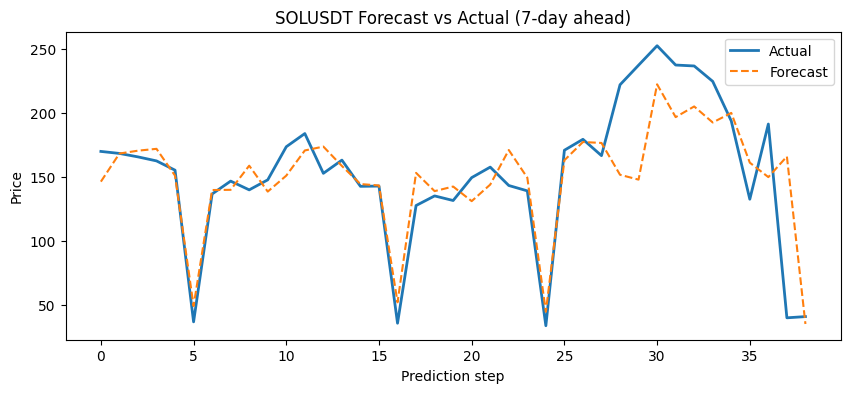


Training: TRXUSDT
TRXUSDT RMSE: 0.056930
TRXUSDT Mean Actual Price: 0.147867
TRXUSDT NRMSE (% of mean price): 0.3850%


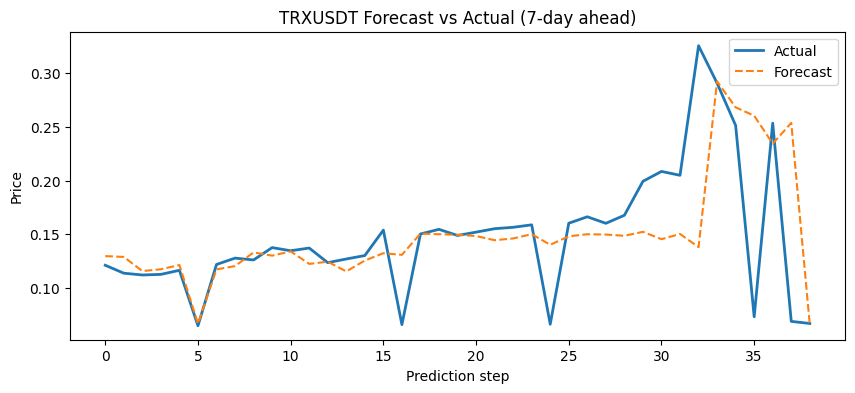


Training: XRPUSDT
XRPUSDT RMSE: 0.490586
XRPUSDT Mean Actual Price: 0.774849
XRPUSDT NRMSE (% of mean price): 0.6331%


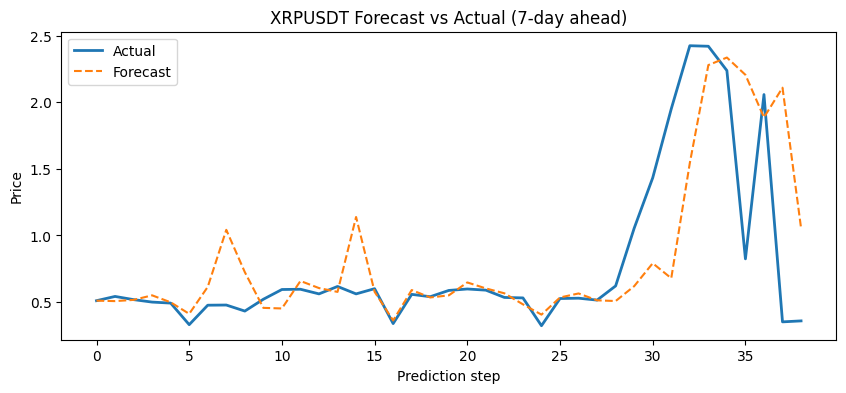

,coin,actual,forecast,returns_predicted
0,ADAUSDT,0.4672,0.430223,-0.017083
1,ADAUSDT,0.4623,0.436188,-0.066378
2,ADAUSDT,0.4470,0.501902,0.085664
3,ADAUSDT,0.4492,0.455375,0.018736
4,ADAUSDT,0.4378,0.444392,-0.010702
...,...,...,...,...
307,XRPUSDT,2.2390,2.336861,-0.035033
308,XRPUSDT,0.8240,2.206910,-0.014332
309,XRPUSDT,2.0587,1.886836,1.289849
310,XRPUSDT,0.3505,2.110292,0.025060



RMSE Summary


,RMSE,Mean_Actual_Price,NRMSE_Mean,NRMSE_Percent
BNBUSDT,91.077701,545.711282,0.166897,0.166897
ETHUSDT,543.011128,2851.582564,0.190424,0.190424
SOLUSDT,32.606461,152.974615,0.213149,0.213149
BTCUSDT,14863.288045,64286.045128,0.231206,0.231206
BCHUSDT,88.484263,367.982051,0.240458,0.240458
ADAUSDT,0.160889,0.528646,0.304341,0.304341
TRXUSDT,0.056930,0.147867,0.385008,0.385008
XRPUSDT,0.490586,0.774849,0.633138,0.633138


In [2]:

import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

#lags to be 2xhorizon, so 2x30 because 30 minutes
data_folder = "klines csv data/prices_cleaned"
HORIZON = 7
N_LAGS = 14

results = {}
all_tables = []

#table of lags
def create_lags(df, n_lags):
    for i in range(1, n_lags + 1):
        df[f"lag_{i}"] = df["close"].shift(i)
    return df

#total files
files = os.listdir(data_folder)

#looping through coins
for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv","")
    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)
    df.columns = ["index","close","time"]

    # ensure numeric just in case
    df["close"] = pd.to_numeric(df["close"], errors="coerce")

    # ensuring chronological order, just in case
    df = df.sort_values("time")

    df = df[["close"]]


    # Handle tiny-price coins

    tiny_price = df["close"].median() < 0.01

    if tiny_price:
        print("Tiny price detected → using log price")
        df["close"] = np.log(df["close"])

    df["target"] = df["close"].shift(-HORIZON)

    df = create_lags(df, N_LAGS)

    df = df.dropna().reset_index(drop=True)

    #train test split
    X = df.drop(columns=["target"])
    y = df["target"]

    split = int(len(df) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    # Model
    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)

    #predict
    preds = []
    actual = []
    current_prices = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]
        current_price_raw = X_test.iloc[i]['close']

        if tiny_price:
            preds.append(np.exp(pred))
            actual.append(np.exp(y_test.iloc[i]))
            current_prices.append(np.exp(current_price_raw))
        else:
            preds.append(pred)
            actual.append(y_test.iloc[i])
            current_prices.append(current_price_raw)

    preds = np.array(preds)
    actual = np.array(actual)
    current_prices = np.array(current_prices)

    # raw RMSE
    rmse = np.sqrt(mean_squared_error(actual, preds))

    # normalize by mean actual price
    mean_actual_price = actual.mean()
    nrmse_mean = rmse / mean_actual_price
    nrmse_pct = nrmse_mean

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Mean": nrmse_mean,
        "NRMSE_Percent": nrmse_pct
    }

    print(f"{coin} RMSE: {rmse:.6f}")
    print(f"{coin} Mean Actual Price: {mean_actual_price:.6f}")
    print(f"{coin} NRMSE (% of mean price): {nrmse_pct:.4f}%")

    # returns_predicted = (forecast - current_price) / current_price
    # gives a true forward-looking expected return signal for CMVO
    table = pd.DataFrame({
        "coin": coin,
        "actual": actual,
        "forecast": preds,
        "returns_predicted": (preds - current_prices) / current_prices
    })

    all_tables.append(table)

    # Plot
    plt.figure(figsize=(10,4))
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(preds, label="Forecast", linestyle="--")
    plt.title(f"{coin} Forecast vs Actual (7-day ahead)")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

#final table
final_table = pd.concat(all_tables, ignore_index=True)

display(final_table)

# save predictions
final_table.to_csv("12 XGB results/xgboost_forecasts.csv", index=False)

#rmse summary
rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("NRMSE_Percent")

rmse_table.to_csv("12 XGB results/RMSE1_normalized.csv", index=True)

print("\nRMSE Summary")
display(rmse_table)


In [3]:
np.save("Results New/XGBoost Base Forecast new return.npy", final_table[["coin", "actual", "forecast", "returns_predicted"]].values)
np.save("12 XGB results/RMSE1_normalized.npy", rmse_table.values)
print("Saved .npy files for Model 1 (Base)")

Saved .npy files for Model 1 (Base)


## Model 2 — XGBoost Features

c:\Users\ameli\Documents\all ur code projects\optimising-dynamic-crypto-portfolio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Files detected: 8
['ADAUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'TRXUSDT', 'XRPUSDT']

Training: ADAUSDT
ADAUSDT RMSE: 0.23214559937900137


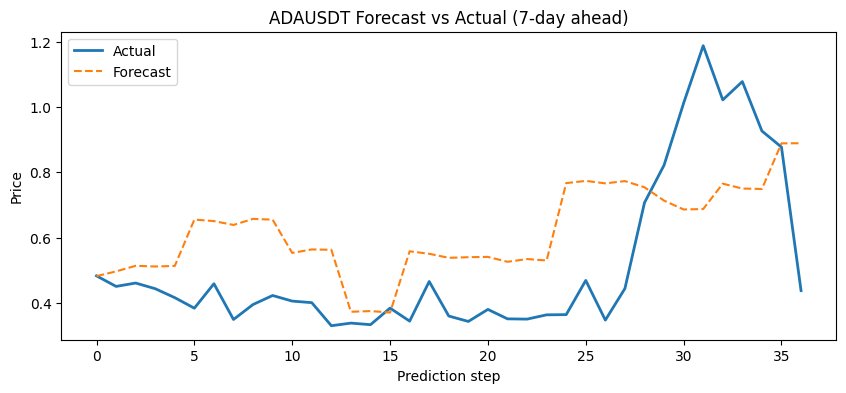


Training: BCHUSDT
BCHUSDT RMSE: 197.0139674373993


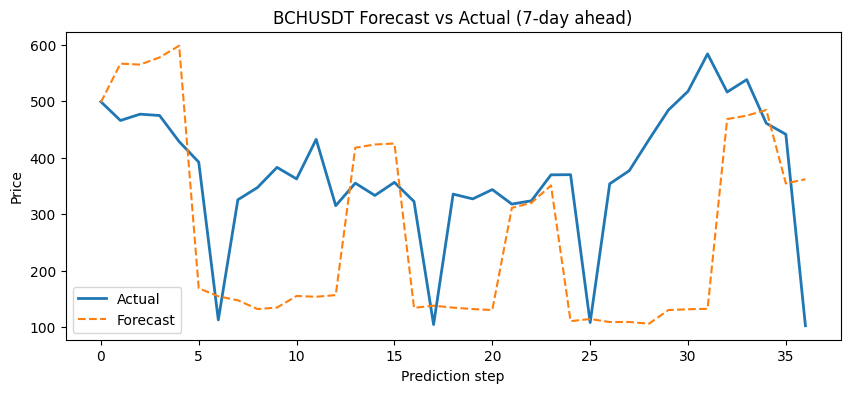


Training: BNBUSDT
BNBUSDT RMSE: 285.7360054027656


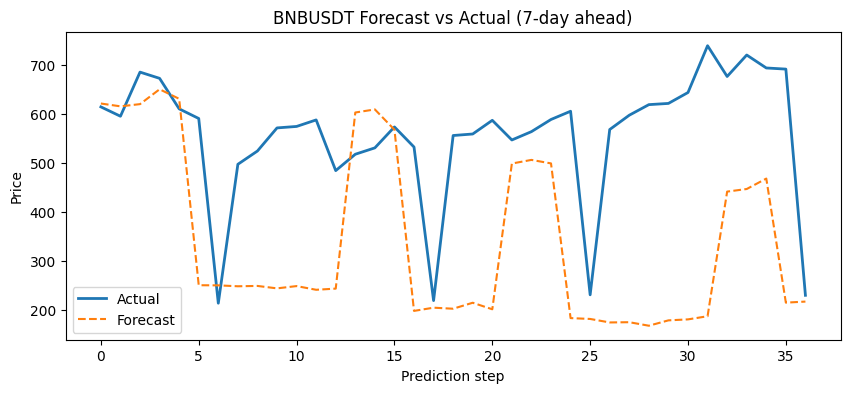


Training: BTCUSDT
BTCUSDT RMSE: 36116.49196802857


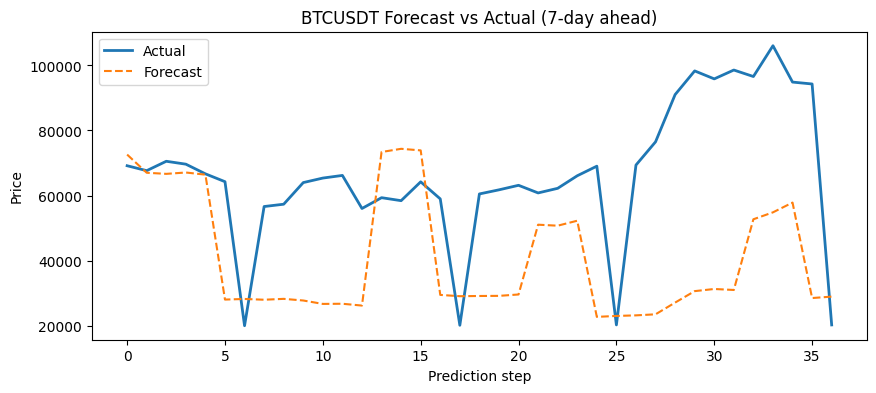


Training: ETHUSDT
ETHUSDT RMSE: 1269.4626584004602


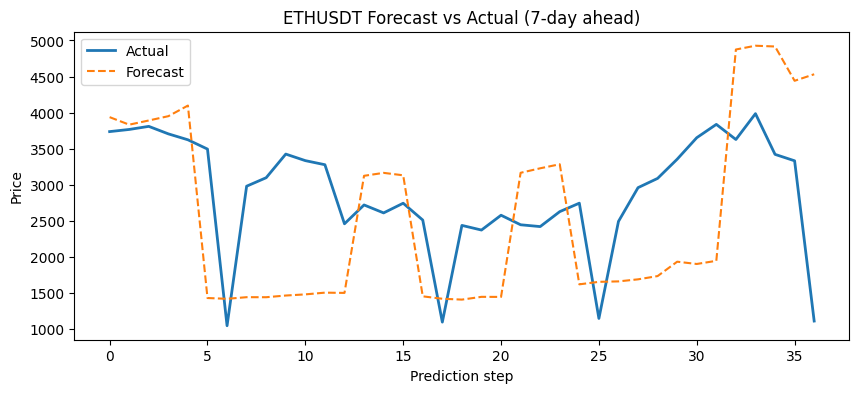


Training: SOLUSDT
SOLUSDT RMSE: 112.78144935719983


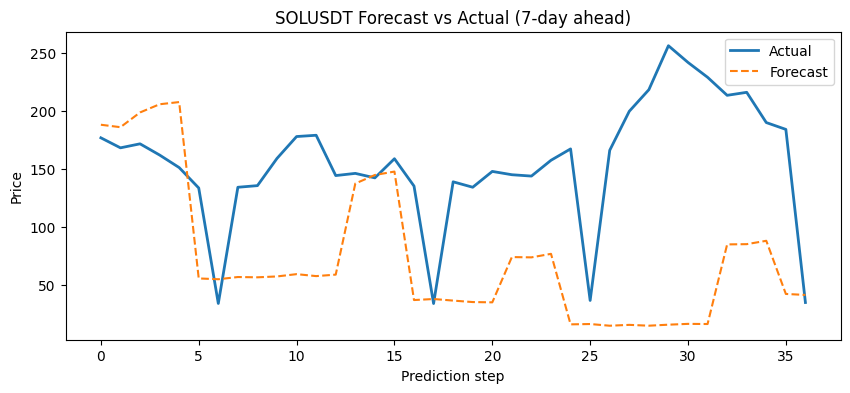


Training: TRXUSDT
TRXUSDT RMSE: 0.09454966702386039


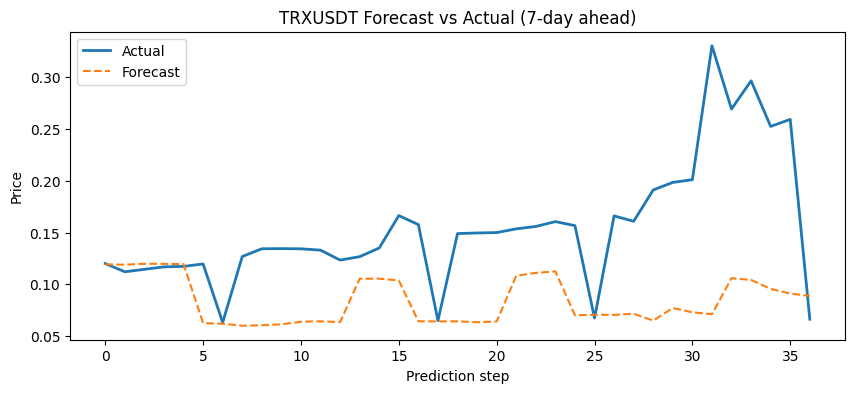


Training: XRPUSDT
XRPUSDT RMSE: 0.600473540026497


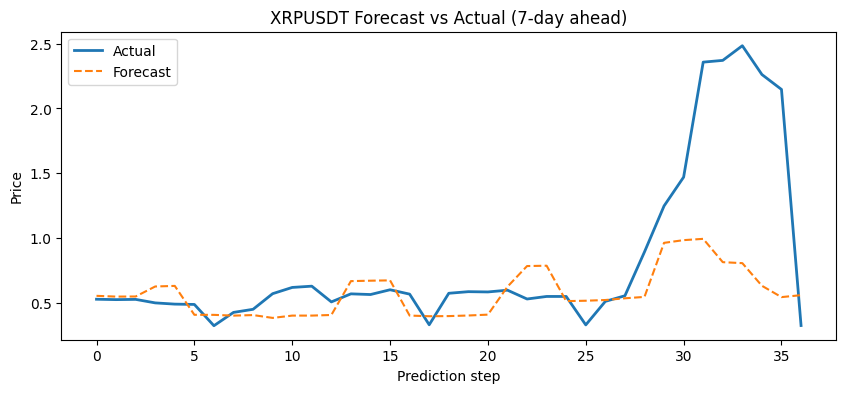

,coin,actual,forecast,returns_predicted
0,ADAUSDT,0.4835,0.482676,-0.001705
1,ADAUSDT,0.4512,0.497078,0.029401
2,ADAUSDT,0.4615,0.514253,0.033968
3,ADAUSDT,0.4442,0.512066,-0.004262
4,ADAUSDT,0.4168,0.513821,0.003421
...,...,...,...,...
32,XRPUSDT,2.3709,0.812999,-0.200086
33,XRPUSDT,2.4841,0.805393,-0.009400
34,XRPUSDT,2.2617,0.630641,-0.244593
35,XRPUSDT,2.1466,0.543172,-0.149311



RMSE Summary


,RMSE,Mean_Actual_Price,NRMSE_Percent
TRXUSDT,0.094550,0.155034,0.609866
ADAUSDT,0.232146,0.516959,0.449060
XRPUSDT,0.600474,0.813641,0.738008
SOLUSDT,112.781449,155.928108,0.723291
BCHUSDT,197.013967,372.651351,0.528682
BNBUSDT,285.736005,558.116486,0.511965
ETHUSDT,1269.462658,2895.692973,0.438397
BTCUSDT,36116.491968,66489.435946,0.543191


In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import optuna

data_folder = "klines csv data/prices_cleaned"

HORIZON = 7
N_LAGS = 14

results = {}
all_tables = []

# Lag funct
def create_lags(df, col, n_lags):

    for i in range(1, n_lags + 1):
        df[f"{col}_lag_{i}"] = df[col].shift(i)

    return df

files = os.listdir(data_folder)

print("Files detected:", len(files))
print(files[:10])

for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv","")

    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)

    df.columns = ["index","close","time"]

    df["close"] = pd.to_numeric(df["close"], errors="coerce")

    df = df.sort_values("time")
    # Returns
    df["return"] = np.log(df["close"] / df["close"].shift(1))


    # rolling vol
    df["vol_30"] = df["return"].rolling(30).std()
    df["vol_60"] = df["return"].rolling(60).std()

    df["target"] = df["return"].shift(-HORIZON)

    df = create_lags(df, "return", N_LAGS)
    df = create_lags(df, "vol_30", 10)
    df = create_lags(df, "vol_60", 10)

    df = df.dropna().reset_index(drop=True)

    X = df.drop(columns=["target","close","time"])
    y = df["target"]

    split = int(len(df) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]
    # Model
    model = xgb.XGBRegressor(

        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42

    )

    model.fit(X_train, y_train)

    preds_return = []
    actual_return = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]

        preds_return.append(pred)

        actual_return.append(y_test.iloc[i])


    actual_price = df["close"].iloc[split::7].values[:len(preds_return)]

    start_price = df["close"].iloc[split]

    preds_price = []

    price = start_price

    for r in preds_return:

        price = price * np.exp(r)

        preds_price.append(price)


    rmse = np.sqrt(mean_squared_error(actual_price, preds_price))
    mean_actual_price = np.mean(actual_price)
    nrmse_percent = (rmse / mean_actual_price)

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Percent": nrmse_percent
    }

    print(f"{coin} RMSE:", rmse)



    table = pd.DataFrame({

        "coin": coin,
        "actual": actual_price,
        "forecast": preds_price,
        "returns_predicted": preds_return

    })

    all_tables.append(table)



    plt.figure(figsize=(10,4))

    plt.plot(actual_price, label="Actual", linewidth=2)
    plt.plot(preds_price, label="Forecast", linestyle="--")

    plt.title(f"{coin} Forecast vs Actual (7-day ahead)")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")

    plt.legend()

    plt.show()



final_table = pd.concat(all_tables)

display(final_table)

final_table.to_csv("12 XGB results/xgb_feature_forecasts.csv", index=False)


rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("RMSE")

print("\nRMSE Summary")
display(rmse_table)
rmse_table.to_csv("12 XGB results/xgb_feature_rmses.csv", index=True)

In [5]:
np.save("Results New/XGBoost Features Forecast new return.npy", final_table[["coin", "actual", "forecast", "returns_predicted"]].values)
np.save("12 XGB results/xgb_feature_rmses.npy", rmse_table.values)
print("Saved .npy files for Model 2 (Features)")

Saved .npy files for Model 2 (Features)


## Model 3 — XGBoost Bayesian Optimised (BO)

In [ ]:

import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import optuna

data_folder = "klines csv data/prices_cleaned"
HORIZON = 7
N_LAGS = 14
VOLATILITY_WINDOW = 7

results = {}
all_tables = []

def create_features(df):
    df = df.copy()

    # log return
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))

    # volatility
    df["volatility"] = df["log_return"].rolling(window=VOLATILITY_WINDOW).std()

    # lagged prices only
    for i in range(1, N_LAGS + 1):
        df[f"lag_{i}"] = df["close"].shift(i)

    return df

files = os.listdir(data_folder)

for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv", "")
    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)
    df.columns = ["index", "close", "time"]

    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df = df.sort_values("time")
    df = df[["close"]]

    # tiny coins
    tiny_price = df["close"].median() < 0.01

    if tiny_price:
        print("Tiny price detected → using log price")
        df["close"] = np.log(df["close"])

    # add features: price lags + volatility only
    df = create_features(df)

    # target = future closing price HORIZON steps ahead
    df["target"] = df["close"].shift(-HORIZON)

    # drop rows with NaN
    df = df.dropna().reset_index(drop=True)

    # exclude target, keep everything else
    X = df.drop(columns=["target"])
    y = df["target"]

    split1 = int(len(df) * 0.6)
    split2 = int(len(df) * 0.8)

    X_train = X.iloc[:split1]
    X_val   = X.iloc[split1:split2]
    X_test  = X.iloc[split2:]

    y_train = y.iloc[:split1]
    y_val   = y.iloc[split1:split2]
    y_test  = y.iloc[split2:]

    print(f"Features used ({len(X.columns)} total):")
    price_lags = [col for col in X.columns if col.startswith("lag_")]
    vol_features = [col for col in X.columns if "vol" in col.lower()]
    other_features = [col for col in X.columns if col not in price_lags and col not in vol_features]

    print(f"  - Price lags: {len(price_lags)} features")
    print(f"  - Volatility features: {len(vol_features)} features")
    print(f"  - Other features: {len(other_features)} features")
    print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}, Test samples: {len(X_test)}")

    # Bayesian Optimisation
    def objective(trial):

        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
            "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
            "objective": "reg:squarederror",
            "random_state": 42
        }

        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train, verbose=False)

        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        return rmse

    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=30, show_progress_bar=True)

    best_params = study.best_params
    print("Best params:", best_params)

    model = xgb.XGBRegressor(
        **best_params,
        objective="reg:squarederror",
        random_state=42
    )

    X_train_full = pd.concat([X_train, X_val], axis=0)
    y_train_full = pd.concat([y_train, y_val], axis=0)

    model.fit(X_train_full, y_train_full, verbose=False)

    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))

    preds = []
    actual = []
    current_prices = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]
        current_price_raw = X_test.iloc[i]['close']

        if tiny_price:
            preds.append(np.exp(pred))
            actual.append(np.exp(y_test.iloc[i]))
            current_prices.append(np.exp(current_price_raw))
        else:
            preds.append(pred)
            actual.append(y_test.iloc[i])
            current_prices.append(current_price_raw)

    preds = np.array(preds)
    actual = np.array(actual)
    current_prices = np.array(current_prices)

    rmse = np.sqrt(mean_squared_error(actual, preds))
    mean_actual_price = np.mean(actual)
    nrmse_percent = (rmse / mean_actual_price)

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Percent": nrmse_percent
    }

    print(f"\n{coin} RMSE: {rmse:.6f}")

    # returns_predicted = (forecast - current_price) / current_price
    # gives a true forward-looking expected return signal for CMVO
    table = pd.DataFrame({
        "coin": coin,
        "actual": actual,
        "forecast": preds,
        "returns_predicted": (preds - current_prices) / current_prices
    })

    all_tables.append(table)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(preds, label="Forecast", linestyle="--")
    plt.title(f"{coin} Forecast vs Actual\nFeatures: Price lags + Volatility")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.scatter(actual, preds, alpha=0.5, s=10)
    min_val = min(min(actual), min(preds))
    max_val = max(max(actual), max(preds))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect prediction")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Prediction Scatter Plot\nRMSE = {rmse:.6f}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

final_table = pd.concat(all_tables, ignore_index=True)
final_table.to_csv("12 XGB results/xgboost_forecasts_BO_price_vol.csv", index=False)

rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("RMSE")

print("\n" + "="*60)
print("RMSE SUMMARY")
print("="*60)
print(rmse_table)
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Mean RMSE: {rmse_table['RMSE'].mean():.6f}")
print(f"Median RMSE: {rmse_table['RMSE'].median():.6f}")
print(f"Mean NRMSE (%): {rmse_table['NRMSE_Percent'].mean():.4f}%")
print(f"Median NRMSE (%): {rmse_table['NRMSE_Percent'].median():.4f}%")
print(f"Best RMSE: {rmse_table['RMSE'].min():.6f} ({rmse_table.index[rmse_table['RMSE'].argmin()]})")
print(f"Worst RMSE: {rmse_table['RMSE'].max():.6f} ({rmse_table.index[rmse_table['RMSE'].argmax()]})")

rmse_table.to_csv("12 XGB results/xgboost_rmse_summary_BO_price_vol.csv")


In [7]:
np.save("Results New/Features and BO new return.npy", final_table[["coin", "actual", "forecast", "returns_predicted"]].values)
np.save("12 XGB results/xgboost_rmse_summary_BO_price_vol.npy", rmse_table.values)
print("Saved .npy files for Model 3 (BO)")

Saved .npy files for Model 3 (BO)
